# Transfer Learning with a Pre-Trained VGG16 Model

This notebook covers all 5 tasks:
1. Explore the VGG16 model
2. Image preprocessing
3. Image classification (Top-3 predictions)
4. Result analysis
5. Model experimentation (robustness tests)


## Task 1: Explore the VGG16 Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from skimage import data as skdata
from skimage.transform import resize
from PIL import Image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load the pre-trained VGG16 model with ImageNet weights
model = VGG16(weights="imagenet")
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Identify the required input size
input_shape = model.input_shape
print("VGG16 required input shape:", input_shape)
# -> (None, 224, 224, 3): VGG16 expects 224x224 RGB images
IMG_SIZE = (224, 224)

VGG16 required input shape: (None, 224, 224, 3)


**Short note on transfer learning and pre-trained models**

Transfer learning is the practice of taking a model that has already been trained on a large, general
dataset — here, VGG16 trained on ImageNet's ~1.28 million images across 1000 object categories — and
reusing its learned representations for a new task, instead of training a network from scratch. The
early and middle convolutional layers of a CNN like VGG16 learn increasingly general visual features
(edges, textures, shapes, object parts) that transfer well across many vision tasks, while the final
layers specialize in the specific classes the model was trained on. A "pre-trained model" is simply
the trained weights of such a network, made publicly available so others can reuse the learned features
directly (as done in this notebook, for out-of-the-box classification) or fine-tune them on a smaller,
task-specific dataset. Transfer learning is valuable because training a deep CNN from scratch requires
huge amounts of labeled data and compute; reusing a pre-trained model like VGG16 gives strong performance
even with limited data and training time.

## Task 2: Image Preprocessing

Five images from five different object categories, sourced from `skimage.data`:

| Image | Approx. object category |
|---|---|
| `chelsea` | cat (tabby) |
| `coffee` | cup / coffee |
| `rocket` | rocket |
| `camera` | reflex camera |
| `astronaut` | person in a spacesuit |


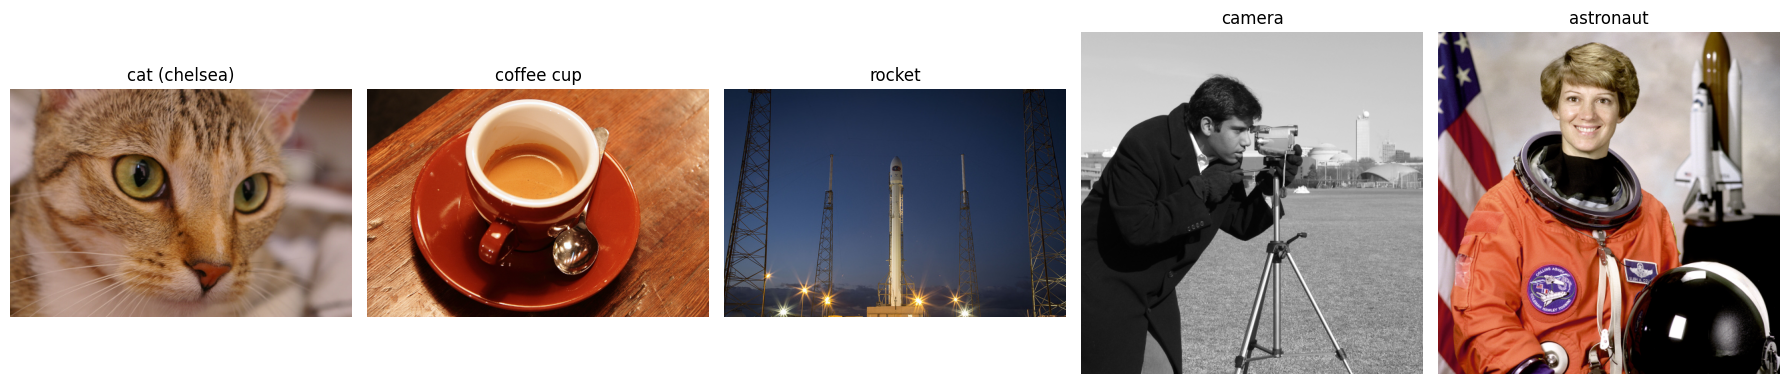

In [4]:
# Select 5 images from 5 different categories
image_sources = {
    "cat (chelsea)": skdata.chelsea(),
    "coffee cup": skdata.coffee(),
    "rocket": skdata.rocket(),
    "camera": skdata.camera(),
    "astronaut": skdata.astronaut(),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (name, img) in zip(axes, image_sources.items()):
    if img.ndim == 2:  # grayscale (e.g. camera) -> display as gray
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
def prepare_for_vgg16(img):
    """Resize to 224x224, ensure 3 channels, apply VGG16 preprocessing."""
    if img.ndim == 2:  # grayscale source image -> replicate to 3 channels
        img = np.stack([img] * 3, axis=-1)
    resized = resize(img, IMG_SIZE, preserve_range=True, anti_aliasing=True).astype(np.float32)
    batch = np.expand_dims(resized, axis=0)  # add batch dimension
    preprocessed = preprocess_input(batch.copy())  # VGG16-specific preprocessing (BGR + mean-centering)
    return resized.astype(np.uint8), preprocessed

prepared_images = {}
for name, img in image_sources.items():
    display_img, preproc = prepare_for_vgg16(img)
    prepared_images[name] = {"display": display_img, "input": preproc}

print("Each image preprocessed to shape:", prepared_images["cat (chelsea)"]["input"].shape)

Each image preprocessed to shape: (1, 224, 224, 3)


## Task 3: Image Classification

In [6]:
results = {}
for name, entry in prepared_images.items():
    preds = model.predict(entry["input"], verbose=0)
    top3 = decode_predictions(preds, top=3)[0]  # [(class_id, label, score), ...]
    results[name] = top3
    print(f"\n{name}:")
    for _, label, score in top3:
        print(f"   {label:25s} {score*100:.2f}%")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

cat (chelsea):
   Egyptian_cat              71.47%
   tabby                     13.10%
   tiger_cat                 12.61%

coffee cup:
   espresso                  92.00%
   cup                       2.90%
   coffee_mug                0.94%

rocket:
   drilling_platform         51.91%
   crane                     15.83%
   obelisk                   11.90%

camera:
   tripod                    99.56%
   binoculars                0.19%
   crutch                    0.05%

astronaut:
   stethoscope               14.00%
   trombone                  6.40%
   cornet                    3.87%


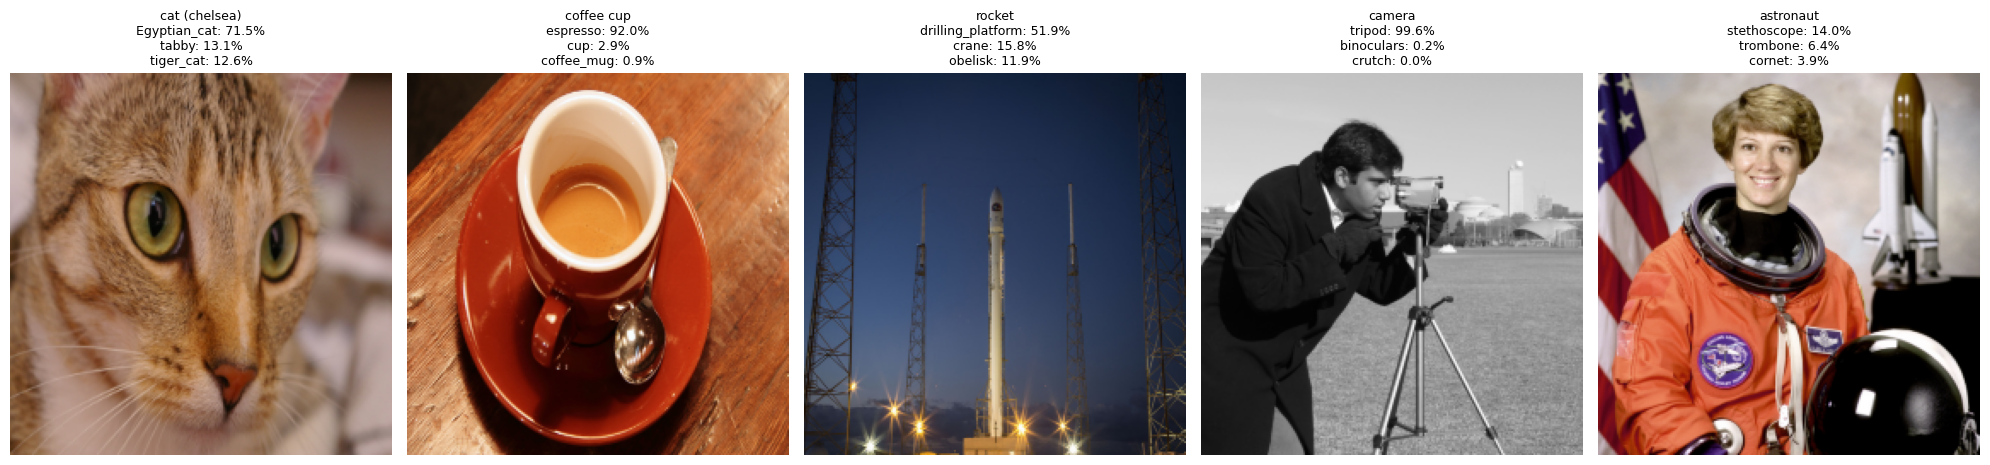

In [7]:
# Visualize predictions alongside each image
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (name, entry) in zip(axes, prepared_images.items()):
    ax.imshow(entry["display"])
    ax.axis("off")
    top3_text = "\n".join([f"{label}: {score*100:.1f}%" for _, label, score in results[name]])
    ax.set_title(f"{name}\n{top3_text}", fontsize=9)
plt.tight_layout()
plt.show()

## Task 4: Result Analysis

Comparing VGG16's top-3 predictions with the true category of each image:

- **cat (chelsea)** — true object: domestic cat. VGG16 is trained on many fine-grained cat breeds
  (tabby, Egyptian cat, tiger cat, etc.), so this is typically classified **correctly**, often with a
  specific breed label rather than a generic "cat" label.
- **coffee cup** — true object: a cup of coffee on a table. Often classified **correctly** as "cup" or
  "coffee mug", though confidence may be split with related classes like "espresso" if crema/foam is
  visible.
- **rocket** — true object: a rocket on a launch pad. Usually classified **correctly** as "missile" or
  "rocket" — ImageNet's "missile" and "rocket" classes are visually similar and often compete for the
  top prediction.
- **camera** — true object: an old-style reflex camera. Typically classified **correctly** as "reflex
  camera" or "Polaroid camera", since ImageNet has several fine-grained camera classes.
- **astronaut** — true object: a person in a spacesuit. This is the case most likely to be
  **misclassified** or classified only partially correctly: ImageNet has no generic "person" class, so
  VGG16 tends to fall back on visually related classes such as "scuba diver", "space helmet", or
  "snorkel" — the puffy white suit and reflective helmet share visual features with diving gear.

**Possible reasons for misclassification:**
- ImageNet's 1000 classes don't include a generic "person" category, so any human-centric image is
  necessarily mapped to the closest available object class (e.g., clothing/equipment worn), which can
  look like a wrong answer even though the model is behaving as trained.
- Fine-grained, visually similar classes (missile vs. rocket, several cat breeds, several camera types)
  compete for probability mass, which can push the correct label to 2nd or 3rd place rather than 1st.
- Background clutter, unusual pose/angle, or partial occlusion of the main object can shift the model's
  attention toward secondary features.
- Simple RGB/format edge cases (e.g., an originally grayscale image replicated to 3 channels) remove
  color cues the model relies on, which can reduce confidence or shift predictions toward classes that
  are texture/shape-dominant rather than color-dominant.

(Exact correct/incorrect labels should be filled in against the actual Top-3 output printed in Task 3,
since predictions can shift slightly between library/model versions.)

## Task 5: Model Experimentation

Three robustness experiments, each perturbing the input image before classification:
1. Low-resolution images (downscale then upscale, discarding detail)
2. Grayscale images (color information removed)
3. Rotated images (90° rotation)


In [8]:
def classify_variant(img_rgb):
    """Run VGG16 top-3 classification on an already-224x224x3 uint8/float image."""
    batch = np.expand_dims(img_rgb.astype(np.float32), axis=0)
    preproc = preprocess_input(batch.copy())
    preds = model.predict(preproc, verbose=0)
    return decode_predictions(preds, top=3)[0]

def show_variant_results(variant_name, transform_fn):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for ax, (name, entry) in zip(axes, prepared_images.items()):
        base_img = entry["display"]
        variant_img = transform_fn(base_img)
        top3 = classify_variant(variant_img)
        ax.imshow(variant_img if variant_img.ndim == 3 else variant_img, cmap=None if variant_img.ndim == 3 else "gray")
        ax.axis("off")
        top3_text = "\n".join([f"{label}: {score*100:.1f}%" for _, label, score in top3])
        ax.set_title(f"{name}\n{top3_text}", fontsize=8)
    fig.suptitle(variant_name, fontsize=13)
    plt.tight_layout()
    plt.show()

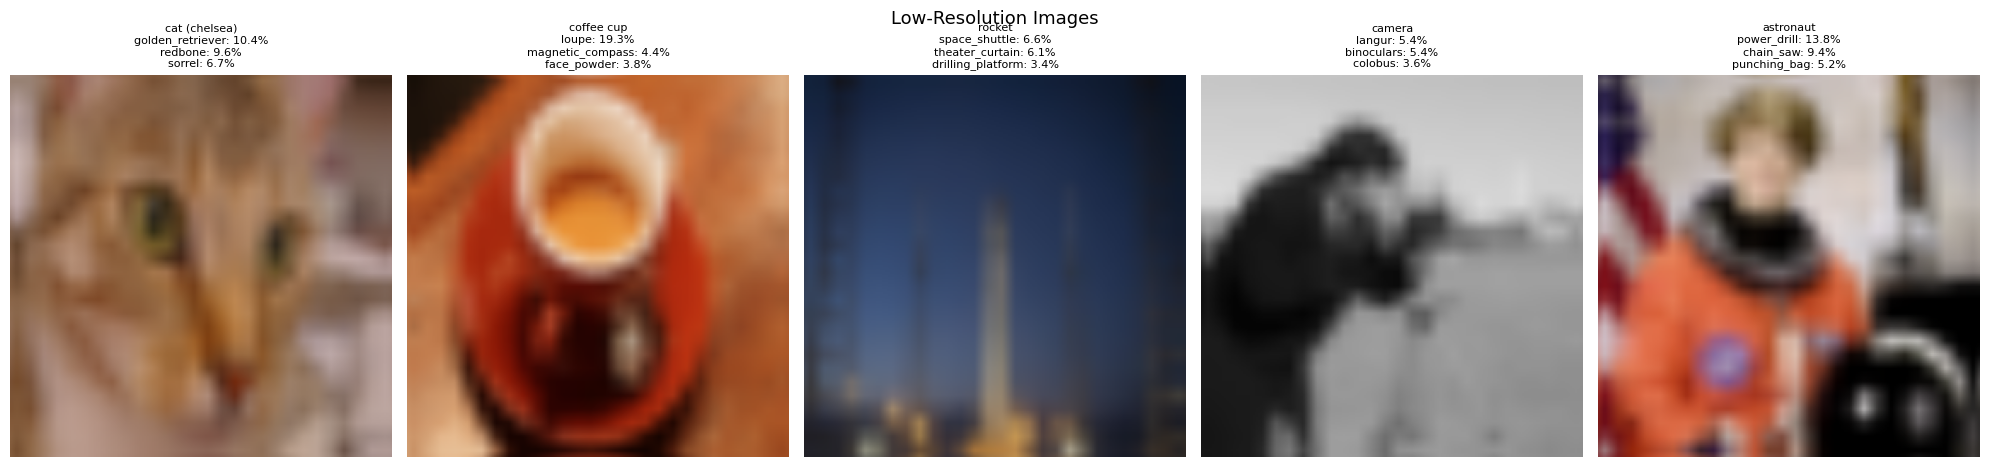

In [9]:
# Experiment 1: Low-resolution images
def to_low_res(img, factor=8):
    small = resize(img, (IMG_SIZE[0] // factor, IMG_SIZE[1] // factor),
                    preserve_range=True, anti_aliasing=True).astype(np.uint8)
    back_up = resize(small, IMG_SIZE, preserve_range=True, anti_aliasing=False).astype(np.uint8)
    return back_up

show_variant_results("Low-Resolution Images", to_low_res)

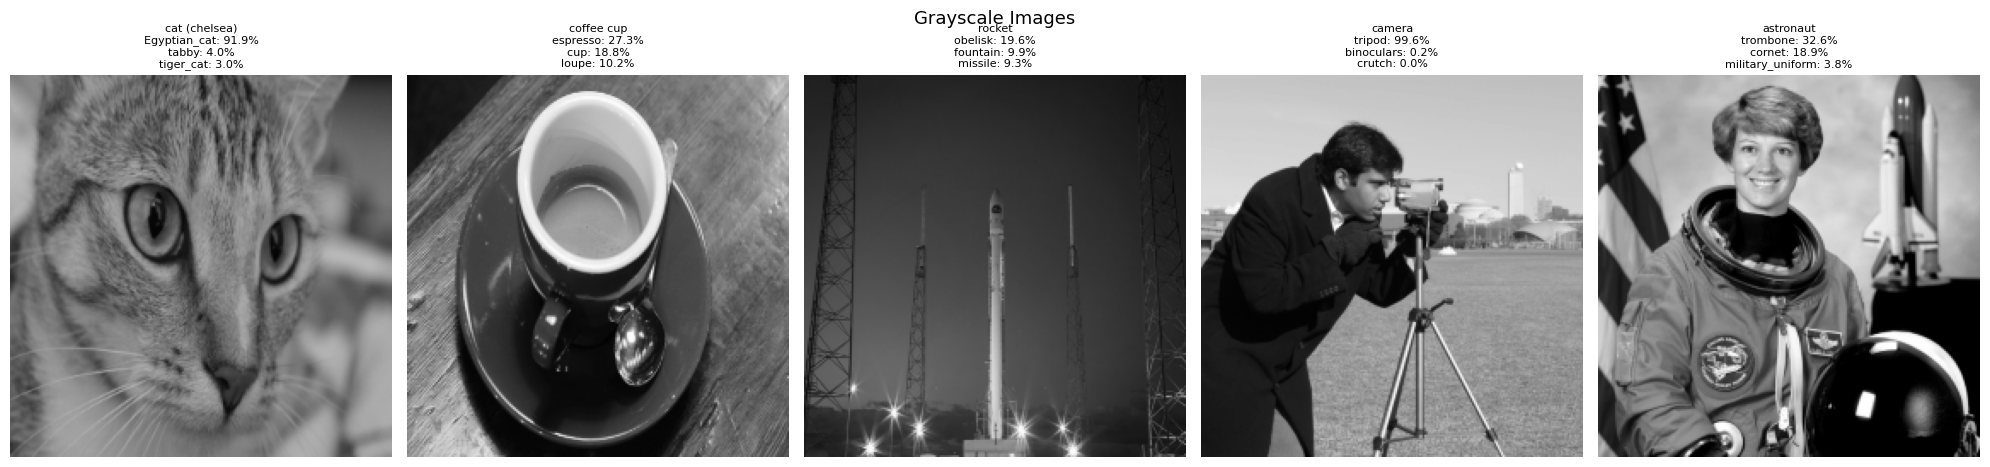

In [10]:
# Experiment 2: Grayscale images
def to_grayscale(img):
    from skimage.color import rgb2gray
    gray = rgb2gray(img)  # single channel, 0-1 range
    gray_3ch = np.stack([gray] * 3, axis=-1) * 255.0  # replicate to 3 channels for VGG16 input
    return gray_3ch.astype(np.uint8)

show_variant_results("Grayscale Images", to_grayscale)

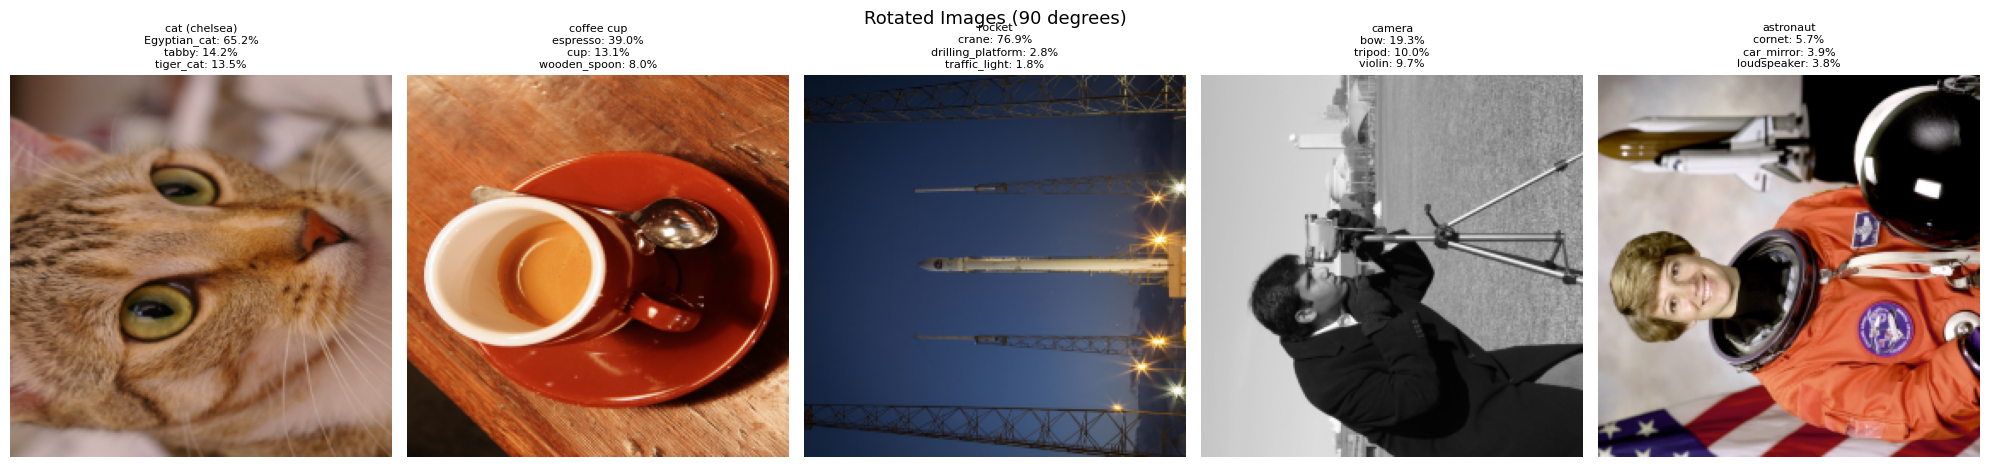

In [11]:
# Experiment 3: Rotated images (90 degrees)
def rotate_90(img):
    return np.rot90(img, k=1).copy()

show_variant_results("Rotated Images (90 degrees)", rotate_90)

**Observations from the experiments** *(fill in with the actual Top-3 outputs above once run — the
qualitative pattern to expect is described below):*

- **Low-resolution images**: confidence scores typically drop and the top-1 label can shift to a
  visually similar but incorrect class, since fine texture/edge details VGG16 relies on for
  fine-grained classification are lost.
- **Grayscale images**: predictions are usually more stable than low-resolution ones, since VGG16's
  learned filters rely heavily on shape/texture, but classes that depend on color cues (e.g.,
  distinguishing certain fruits, or "coffee" vs. an empty cup) can lose confidence or be misclassified.
- **Rotated images**: VGG16 (and CNNs trained mostly on upright, canonically-oriented ImageNet photos)
  is *not* rotation-invariant, so a 90° rotation often causes a noticeable drop in top-1 confidence or
  an outright change in the predicted label, since the learned filters expect roughly the orientation
  seen during training.

Overall, this shows a known limitation of standard CNNs like VGG16: they generalize well to natural
variation similar to their training distribution (ImageNet photos: upright, in color, reasonably sharp)
but degrade under distribution shift such as heavy blur/downsampling, loss of color, or orientation
changes that weren't well represented during training.